# 01 — Carregamento e Limpeza dos Dados

**Dataset:** Microdados do ENEM 2023 (INEP)  
**Objetivo:** Carregar uma amostra de 500 mil candidatos, inspecionar qualidade dos dados, aplicar limpeza e exportar o dataset processado para os notebooks seguintes.

**Etapas:**
1. Carregamento direto do arquivo ZIP
2. Inspeção inicial (shape, tipos, primeiros registros)
3. Análise de valores ausentes
4. Filtragem e transformação
5. Exportação para `data/processed/`

In [1]:
import sys
import zipfile
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../src')
from utils import (
    NOTAS_COLS, NOTAS_LABELS,
    MAPA_ESCOLA, MAPA_COR_RACA, MAPA_RENDA,
    configurar_estilo, salvar_figura
)

configurar_estilo()

## 1. Carregamento dos Dados

In [2]:
ZIP_PATH       = '../data/raw/microdados_enem_2023.zip'
PROCESSED_PATH = '../data/processed/amostra_limpa.parquet'
N_AMOSTRA      = 500_000

COLUNAS_INTERESSE = [
    'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO',
    'Q006',        # faixa de renda familiar
    'TP_ESCOLA',   # tipo de escola
    'SG_UF_PROVA', # estado
    'TP_SEXO',     # sexo
    'TP_COR_RACA', # cor/raça autodeclarada
]

In [3]:
print('Carregando dados do arquivo ZIP...')
t0 = time.time()

with zipfile.ZipFile(ZIP_PATH) as z:
    # O ZIP contém também ITENS_PROVA; seleciona o maior CSV (MICRODADOS_ENEM_2023.csv)
    csvs = [f for f in z.namelist() if f.lower().endswith('.csv')]
    csv_nome = max(csvs, key=lambda f: z.getinfo(f).file_size)
    print(f'  Arquivo CSV encontrado: {csv_nome}')

    with z.open(csv_nome) as f:
        df_raw = pd.read_csv(
            f,
            sep=';',
            encoding='latin-1',
            usecols=COLUNAS_INTERESSE,
            nrows=N_AMOSTRA,
            low_memory=False,
        )

print(f'  Tempo de leitura: {time.time() - t0:.1f}s')
print(f'  Shape carregado: {df_raw.shape}')

Carregando dados do arquivo ZIP...
  Arquivo CSV encontrado: DADOS/MICRODADOS_ENEM_2023.csv
  Tempo de leitura: 3.1s
  Shape carregado: (500000, 10)


## 2. Inspeção Inicial

In [4]:
df_raw.head(3)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006
0,M,1,1,DF,NaN,NaN,NaN,NaN,NaN,F
1,M,1,1,DF,NaN,NaN,NaN,NaN,NaN,H
2,F,1,1,RS,502.0,498.9,475.6,363.2,700.0,C


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TP_SEXO          500000 non-null  object 
 1   TP_COR_RACA      500000 non-null  int64  
 2   TP_ESCOLA        500000 non-null  int64  
 3   SG_UF_PROVA      500000 non-null  object 
 4   NU_NOTA_CN       371392 non-null  float64
 5   NU_NOTA_CH       386769 non-null  float64
 6   NU_NOTA_LC       386769 non-null  float64
 7   NU_NOTA_MT       371392 non-null  float64
 8   NU_NOTA_REDACAO  386769 non-null  float64
 9   Q006             500000 non-null  object 
dtypes: float64(5), int64(2), object(3)
memory usage: 38.1+ MB


In [6]:
df_raw.describe().round(2)

,TP_COR_RACA,TP_ESCOLA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
count,500000.00,500000.00,371392.00,386769.00,386769.00,371392.00,386769.00
mean,2.11,1.45,490.73,523.37,517.58,524.03,639.61
std,0.99,0.58,84.90,85.75,73.42,127.10,210.42
min,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,436.70,469.50,471.80,425.70,520.00
50%,2.00,1.00,486.50,528.90,521.40,510.00,640.00
75%,3.00,2.00,543.10,582.30,567.80,614.00,800.00
max,5.00,3.00,868.40,823.00,820.80,958.60,1000.00


## 3. Análise de Valores Ausentes

No ENEM, um candidato inscrito pode não comparecer às provas — nesse caso todas as notas ficam como `NaN`. Candidatos ausentes não são úteis para análise de desempenho e precisam ser removidos.

In [7]:
ausentes = df_raw.isna().sum().sort_values(ascending=False)
ausentes_pct = (ausentes / len(df_raw) * 100).round(2)

resumo_ausentes = pd.DataFrame({
    'Ausentes': ausentes,
    '% Ausentes': ausentes_pct
})
print(resumo_ausentes.to_string())

                 Ausentes  % Ausentes
NU_NOTA_CN         128608       25.72
NU_NOTA_MT         128608       25.72
NU_NOTA_CH         113231       22.65
NU_NOTA_LC         113231       22.65
NU_NOTA_REDACAO    113231       22.65
TP_SEXO                 0        0.00
TP_COR_RACA             0        0.00
TP_ESCOLA               0        0.00
SG_UF_PROVA             0        0.00
Q006                    0        0.00


Figura salva: ../reports/figures/01_valores_ausentes.png


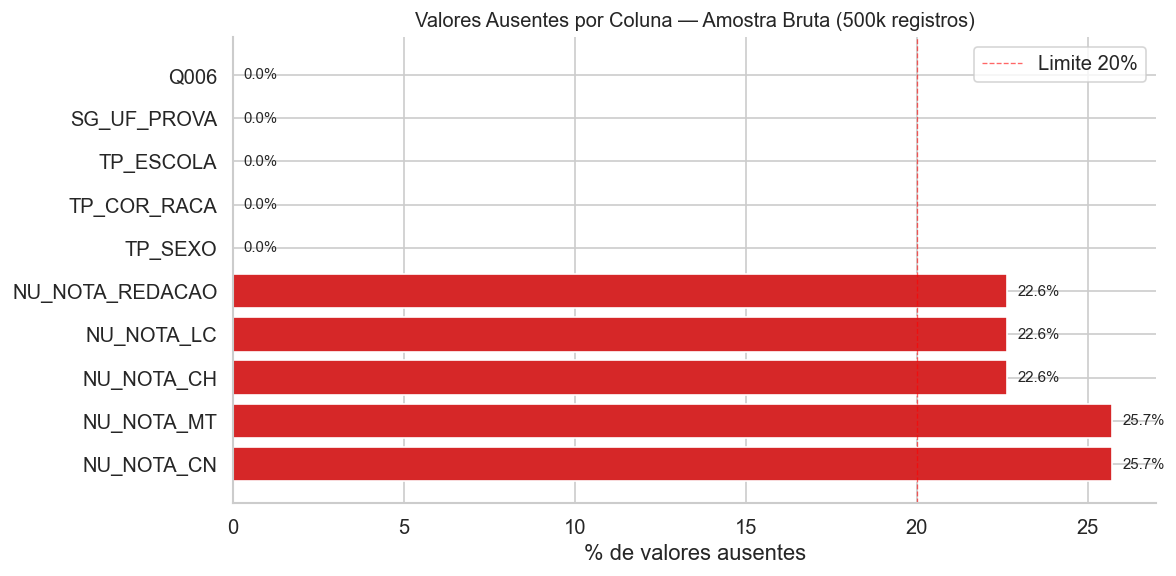

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

cores = ['#d62728' if p > 20 else '#1f77b4' for p in ausentes_pct.values]
bars = ax.barh(ausentes_pct.index, ausentes_pct.values, color=cores)

for bar, val in zip(bars, ausentes_pct.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('% de valores ausentes')
ax.set_title('Valores Ausentes por Coluna — Amostra Bruta (500k registros)', fontsize=12)
ax.axvline(20, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='Limite 20%')
ax.legend()
plt.tight_layout()
salvar_figura(fig, '01_valores_ausentes')
plt.show()

## 4. Filtragem e Transformação

### 4.1 — Remover ausentes nas provas

**`NaN` ≠ `0` no dataset do ENEM:**

| Valor | Significado |
|---|---|
| `NaN` | Candidato **ausente** — não compareceu naquele dia de prova |
| `0.0` | Candidato **presente** — compareceu mas zerou a nota |

O filtro abaixo remove apenas os `NaN` (ausentes). Candidatos com nota `0` são mantidos, pois participaram do exame.

**Estrutura dos dias de prova:**
- **Dia 1** → CN + MT (2 notas)
- **Dia 2** → CH + LC + Redação (3 notas)

Como CN e MT são sempre aplicadas juntas, e CH/LC/Redação também, o critério `>= 4` notas preenchidas na prática **mantém apenas candidatos que compareceram aos dois dias**. Candidatos que foram só a um dia têm no máximo 3 notas preenchidas e são excluídos.

Essa decisão garante que a comparação de desempenho seja feita em base igual — apenas quem realizou o exame completo.

In [9]:
df = df_raw[df_raw[NOTAS_COLS].notna().sum(axis=1) >= 4].copy()

removidos = len(df_raw) - len(df)
print(f'Registros removidos (ausentes): {removidos:,} ({removidos / len(df_raw) * 100:.1f}%)')
print(f'Registros restantes:            {len(df):,}')

Registros removidos (ausentes): 129,859 (26.0%)
Registros restantes:            370,141


### 4.2 — Aplicar mapeamentos de categorias

In [10]:
df['TP_ESCOLA']   = df['TP_ESCOLA'].map(MAPA_ESCOLA)
df['TP_COR_RACA'] = df['TP_COR_RACA'].map(MAPA_COR_RACA)
df['Q006']        = df['Q006'].map(MAPA_RENDA)
df['TP_SEXO']     = df['TP_SEXO'].map({'M': 'Masculino', 'F': 'Feminino'})

print('Tipos após mapeamento:')
print(df.dtypes)

Tipos após mapeamento:
TP_SEXO             object
TP_COR_RACA         object
TP_ESCOLA           object
SG_UF_PROVA         object
NU_NOTA_CN         float64
NU_NOTA_CH         float64
NU_NOTA_LC         float64
NU_NOTA_MT         float64
NU_NOTA_REDACAO    float64
Q006                object
dtype: object


### 4.3 — Criar coluna de nota média

In [11]:
df['NOTA_MEDIA'] = df[NOTAS_COLS].mean(axis=1).round(2)

print('Estatísticas da nota média:')
print(df['NOTA_MEDIA'].describe().round(2))

Estatísticas da nota média:
count    370141.00
mean        541.55
std          93.16
min           0.00
25%         477.86
50%         538.76
75%         604.74
max         847.06
Name: NOTA_MEDIA, dtype: float64


### 4.4 — Converter colunas categóricas

In [12]:
cols_cat = ['TP_ESCOLA', 'TP_COR_RACA', 'Q006', 'TP_SEXO', 'SG_UF_PROVA']
for col in cols_cat:
    df[col] = df[col].astype('category')

print('Shape final:', df.shape)
print(f'Uso de memória: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

Shape final: (370141, 11)
Uso de memória: 21.5 MB


## 5. Verificação Final

In [13]:
print('=== Dataset limpo ===')
print(f'Shape: {df.shape}')
print()
print('Distribuição por tipo de escola:')
print(df['TP_ESCOLA'].value_counts())
print()
print('Distribuição por sexo:')
print(df['TP_SEXO'].value_counts())
print()
print('Ausentes remanescentes:')
print(df.isna().sum()[df.isna().sum() > 0])

=== Dataset limpo ===
Shape: (370141, 11)

Distribuição por tipo de escola:
TP_ESCOLA
Não respondeu    201054
Pública          147648
Privada           21439
Name: count, dtype: int64

Distribuição por sexo:
TP_SEXO
Feminino     256157
Masculino    113984
Name: count, dtype: int64

Ausentes remanescentes:
Q006    3312
dtype: int64


In [14]:
df.head(3)

,TP_SEXO,TP_COR_RACA,TP_ESCOLA,SG_UF_PROVA,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q006,NOTA_MEDIA
2,Feminino,Branca,Não respondeu,RS,502.0,498.9,475.6,363.2,700.0,R$ 1.320 – R$ 1.980,507.94
3,Feminino,Parda,Pública,CE,459.0,508.5,507.2,466.7,880.0,R$ 1.320 – R$ 1.980,564.28
4,Feminino,Parda,Pública,CE,402.5,379.2,446.9,338.3,560.0,Até R$ 1.320,425.38


## 6. Exportação

In [15]:
df.to_parquet(PROCESSED_PATH, index=False, engine='pyarrow')
print(f'Dataset salvo em: {PROCESSED_PATH}')
print(f'Shape exportado:  {df.shape}')

Dataset salvo em: ../data/processed/amostra_limpa.parquet
Shape exportado:  (370141, 11)


---
## Resumo

| Etapa | Resultado |
|---|---|
| Registros carregados | 500.000 |
| Removidos (ausentes nas provas) | ver célula acima |
| Colunas no dataset final | 11 (10 originais + `NOTA_MEDIA`) |
| Formato de saída | Parquet (menor, mais rápido que CSV) |

**Próximo passo:** `02_analise_univariada.ipynb` — distribuições das notas e variáveis categóricas.